<a href="https://colab.research.google.com/github/serendipity343/Machine-learning/blob/Task-1%262/task2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction
This colab worksheet provides a starting point for Task 2 (the computer vision task).

In [1]:
import google
google.colab.drive.mount('/content/gdrive')

Mounted at /content/gdrive


# Data Loading

In [2]:
# Download the data stored in a zipped numpy array from one of these two locations
# If you're running all your experiments
# on a machine at home rather than using colab, then make sure you save it
# rather than repeatedly downloading it.

!wget "https://sussex.box.com/shared/static/wrlmcs47dstkmfz2eckgg5d2l0liusr5" -O face_alignment_training_images.npz

# The test images (without points)
!wget "https://sussex.box.com/shared/static/8n5ofhb9so0ia85g4bbcmnt3h6z53m9a" -O face_alignment_test_images.npz

--2025-04-28 18:56:36--  https://sussex.box.com/shared/static/wrlmcs47dstkmfz2eckgg5d2l0liusr5
Resolving sussex.box.com (sussex.box.com)... 74.112.186.157, 2620:117:bff0:12d::
Connecting to sussex.box.com (sussex.box.com)|74.112.186.157|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: /public/static/wrlmcs47dstkmfz2eckgg5d2l0liusr5 [following]
--2025-04-28 18:56:36--  https://sussex.box.com/public/static/wrlmcs47dstkmfz2eckgg5d2l0liusr5
Reusing existing connection to sussex.box.com:443.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://sussex.app.box.com/public/static/wrlmcs47dstkmfz2eckgg5d2l0liusr5 [following]
--2025-04-28 18:56:36--  https://sussex.app.box.com/public/static/wrlmcs47dstkmfz2eckgg5d2l0liusr5
Resolving sussex.app.box.com (sussex.app.box.com)... 74.112.186.157, 2620:117:bff0:12d::
Connecting to sussex.app.box.com (sussex.app.box.com)|74.112.186.157|:443... connected.
HTTP request sent, awaiting resp

# Check the data downloaded correctly
If any of these assertions fail, redownload the data

In [3]:
def confirm_checksum(filename, true_checksum):
  import subprocess
  checksum = subprocess.check_output(['shasum',filename]).decode('utf-8')
  print (checksum)
  assert checksum.split(' ')[0] == true_checksum, 'Checksum does not match for ' + filename + ' redownload the data.'

confirm_checksum('face_alignment_training_images.npz', 'affc56216e34c827f10681a14c602981c06ddeb3')
confirm_checksum('face_alignment_test_images.npz', 'e480535442512b8175ae110d2d3e507378cabbdb')

affc56216e34c827f10681a14c602981c06ddeb3  face_alignment_training_images.npz

e480535442512b8175ae110d2d3e507378cabbdb  face_alignment_test_images.npz



# Load the data

Import necessary packages

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.linear_model import Ridge
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import cv2
import os

In [5]:
# Load the data using np.load
data = np.load('/content/gdrive/MyDrive/350/face_alignment_training_images.npz', allow_pickle=True)

# Extract the images
images = data['images']
# And the data points
pts = data['points']

print(images.shape, pts.shape)

test_data = np.load('/content/gdrive/MyDrive/350/face_alignment_test_images.npz', allow_pickle=True)
test_images = test_data['images']
print(test_images.shape)

(2811, 256, 256, 3) (2811, 5, 2)
(554, 256, 256, 3)


# Data Visualisation
Here's an example of how to display the images and their points


Sample 1527 - Point Coordinates:
Point 0: (96.7, 102.8)
Point 1: (166.3, 104.7)
Point 2: (102.6, 138.3)
Point 3: (104.9, 186.3)
Point 4: (144.9, 188.2)


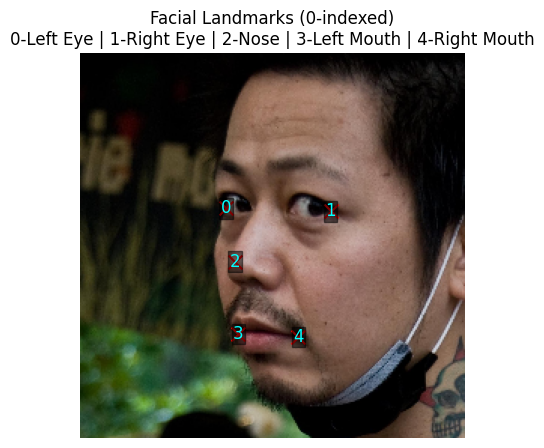


Sample 2558 - Point Coordinates:
Point 0: (84.6, 112.1)
Point 1: (170.1, 94.9)
Point 2: (100.2, 124.0)
Point 3: (91.9, 177.8)
Point 4: (154.8, 173.9)


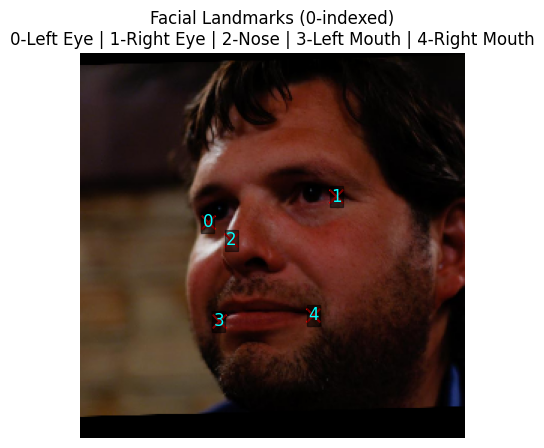


Sample 1683 - Point Coordinates:
Point 0: (79.1, 99.9)
Point 1: (179.9, 107.2)
Point 2: (127.9, 153.6)
Point 3: (91.0, 173.1)
Point 4: (157.6, 179.9)


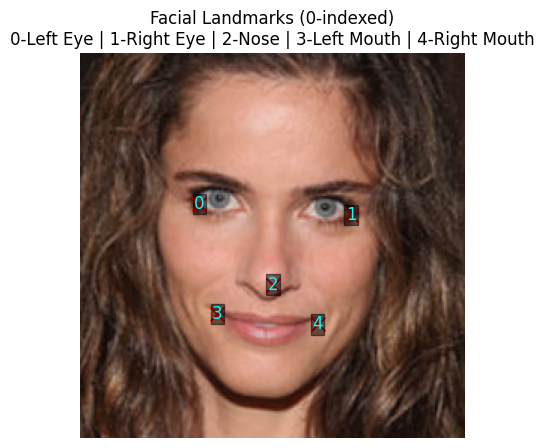

In [6]:
def visualize_pts(img, pts, show_indices=True):
    """
    Visualize facial landmarks with optional index labels

    Args:
        img: Input image (H,W,3)
        pts: Facial points (N,2)
        show_indices: Whether to display point indices
    """
    plt.figure(figsize=(5,5))
    plt.imshow(img)

    # Plot points with red crosses
    plt.scatter(pts[:,0], pts[:,1], c='red', marker='x', s=100)

    # Annotate each point with its index
    if show_indices:
        for i, (x, y) in enumerate(pts):
            plt.text(x, y, str(i), color='cyan', fontsize=12,
                    ha='center', va='center',
                    bbox=dict(facecolor='black', alpha=0.5, pad=1))

    # Add point location guide
    plt.title("Facial Landmarks (0-indexed)\n"
              "0-Left Eye | 1-Right Eye | 2-Nose | 3-Left Mouth | 4-Right Mouth",
              fontsize=12)
    plt.axis('off')
    plt.show()

# Visualize 3 random samples with point indices
for i in range(3):
    idx = np.random.randint(0, images.shape[0])
    print(f"\nSample {idx} - Point Coordinates:")
    for pt_idx, (x, y) in enumerate(pts[idx]):
        print(f"Point {pt_idx}: ({x:.1f}, {y:.1f})")

    visualize_pts(images[idx], pts[idx])

# Calculating Prediction Error and exporting results

In [23]:
def euclid_dist(pred_pts, gt_pts):
  """
  Calculate the euclidean distance between pairs of points
  :param pred_pts: The predicted points
  :param gt_pts: The ground truth points
  :return: An array of shape (no_points,) containing the distance of each predicted point from the ground truth
  """
  pred_pts = np.reshape(pred_pts, (-1, 2))
  gt_pts = np.reshape(gt_pts, (-1, 2))
  return np.sqrt(np.sum(np.square(pred_pts - gt_pts), axis=-1))


In [8]:
# Function to extract SIFT features
def extract_sift_features(image, grid_size=5):
    if image.ndim == 3:
        image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    h, w = image.shape
    keypoints = []
    step_x, step_y = w // grid_size, h // grid_size
    for y in range(step_y // 2, h, step_y):
        for x in range(step_x // 2, w, step_x):
            keypoints.append(cv2.KeyPoint(x, y, 1))
    sift = cv2.SIFT_create()
    _, descriptors = sift.compute(image, keypoints)
    if descriptors is None:
        descriptors = np.zeros((grid_size * grid_size, 128))
    return descriptors.flatten()

# Prepare data for three diferent models

In [9]:
# Prepare data for traditional models (SVR and Ridge)
X = np.array([extract_sift_features(img) for img in images])
y = pts.reshape(len(pts), -1)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
# Prepare data for CNN
data = np.load('face_alignment_training_images.npz', allow_pickle=True)
images = data['images'].astype('float32') / 255.0
pts = data['points'].reshape(len(data['points']), -1)  # (N, 10)

images_train, images_val, y_train_cnn, y_val_cnn = train_test_split(
    images, pts.reshape(len(pts), -1), test_size=0.2, random_state=42)
y_train_cnn = y_train_cnn.reshape(-1, 10)
y_val_cnn = y_val_cnn.reshape(-1, 10)

# Train three different models

In [11]:
print("\nTraining Ridge Regression...")
ridge_model = MultiOutputRegressor(Ridge(alpha=1.0))
ridge_model.fit(X_train, y_train)

# Predict on validation set
y_val_pred_ridge = ridge_model.predict(X_val)

# Calculate Euclidean distances for each sample
point_distances = np.linalg.norm(y_val_pred_ridge - y_val, axis=1)

# Calculate mean and std separately
ridge_mean_error = np.mean(point_distances)
ridge_std_error = np.std(point_distances)
ridge_errors = (ridge_mean_error, ridge_std_error)  # Store as tuple

print(f"Ridge Regression - Mean Error: {ridge_mean_error:.2f} ± {ridge_std_error:.2f}")


Training Ridge Regression...
Ridge Regression - Mean Error: 45.27 ± 16.05


In [12]:
print("\nTraining SVR...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

svr_model = MultiOutputRegressor(SVR(kernel='rbf', C=1.0, epsilon=0.1))
svr_model.fit(X_train_scaled, y_train)

# Predict on validation set
y_val_pred_svr = svr_model.predict(X_val_scaled)

# Calculate errors in one clear step
svr_errors = np.linalg.norm(y_val_pred_svr - y_val, axis=1)
svr_mean_error = np.mean(svr_errors)
svr_std_error = np.std(svr_errors)

# Your preferred output format
print(f"SVR - Mean Error: {svr_mean_error:.2f} ± {svr_std_error:.2f}")



Training SVR...
SVR - Mean Error: 25.20 ± 11.90



Training optimized CNN model...
Epoch 1/30


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


18/18 ━━━━━━━━━━━━━━━━━━━━ 132s 7s/step - loss: 19328.0293 - mae: 134.2497 - val_loss: 19341.7266 - val_mae: 134.2788 - learning_rate: 0.0010
Epoch 2/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 126s 7s/step - loss: 18783.4414 - mae: 132.2370 - val_loss: 19164.8848 - val_mae: 133.6515 - learning_rate: 0.0010
Epoch 3/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 132s 7s/step - loss: 17716.4277 - mae: 128.1122 - val_loss: 18224.7676 - val_mae: 130.2426 - learning_rate: 0.0010
Epoch 4/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 138s 7s/step - loss: 16014.8301 - mae: 121.1070 - val_loss: 16689.1543 - val_mae: 124.3488 - learning_rate: 0.0010
Epoch 5/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 125s 7s/step - loss: 13518.6182 - mae: 109.6837 - val_loss: 15388.6250 - val_mae: 119.0375 - learning_rate: 0.0010
Epoch 6/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 144s 8s/step - loss: 10630.9922 - mae: 94.1785 - val_loss: 12424.9365 - val_mae: 105.7858 - learning_rate: 0.0010
Epoch 7/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 126s 7s/step - loss: 8108.2749 - mae: 78.0756 - val_loss

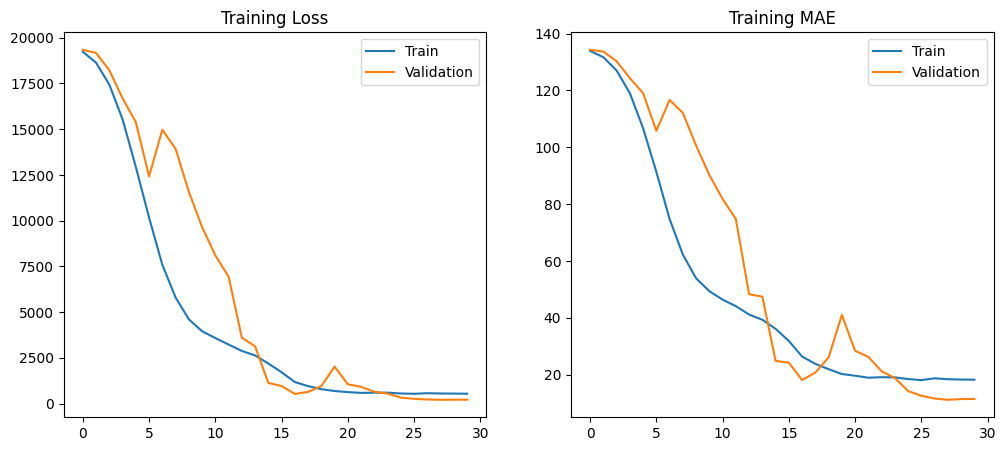


Final Performance Metrics:
Mean Error: 41.45 ± 20.47 pixels
Median Error: 37.10 pixels
Max Error: 159.19 pixels


In [13]:
# Create optimized data pipeline
def create_dataset(X, y, batch_size=128, shuffle=True):
    """Create efficient TensorFlow data pipeline"""
    dataset = tf.data.Dataset.from_tensor_slices((X, y))
    if shuffle:
        dataset = dataset.shuffle(buffer_size=1024)
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    return dataset

train_ds = create_dataset(images_train, y_train)
val_ds = create_dataset(images_val, y_val, shuffle=False)

# Build lightweight model
def build_lightweight_model(input_shape=(256, 256, 3)):
    model = models.Sequential([
        layers.Conv2D(32, (5,5), strides=2, activation='relu', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),

        layers.Conv2D(64, (3,3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),

        layers.Conv2D(128, (3,3), activation='relu'),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling2D(),

        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(10)
    ])
    return model

# Compile model
cnn_model = build_lightweight_model()
cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

# Configure callbacks
callbacks_list = [
    callbacks.EarlyStopping(patience=8, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(factor=0.5, patience=3)
]

# Train model
print("\nTraining optimized CNN model...")
history = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=callbacks_list,
    verbose=1
)

# Evaluate model
print("\nEvaluating model performance...")
y_val_pred_cnn = cnn_model.predict(val_ds)
cnn_errors = np.linalg.norm(y_val_pred_cnn - y_val, axis=1)

# Visualize training history
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Training Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['mae'], label='Train')
plt.plot(history.history['val_mae'], label='Validation')
plt.title('Training MAE')
plt.legend()
plt.show()

print(f"\nFinal Performance Metrics:")
print(f"Mean Error: {np.mean(cnn_errors):.2f} ± {np.std(cnn_errors):.2f} pixels")
print(f"Median Error: {np.median(cnn_errors):.2f} pixels")
print(f"Max Error: {np.max(cnn_errors):.2f} pixels")

# Error Distribution Comparison

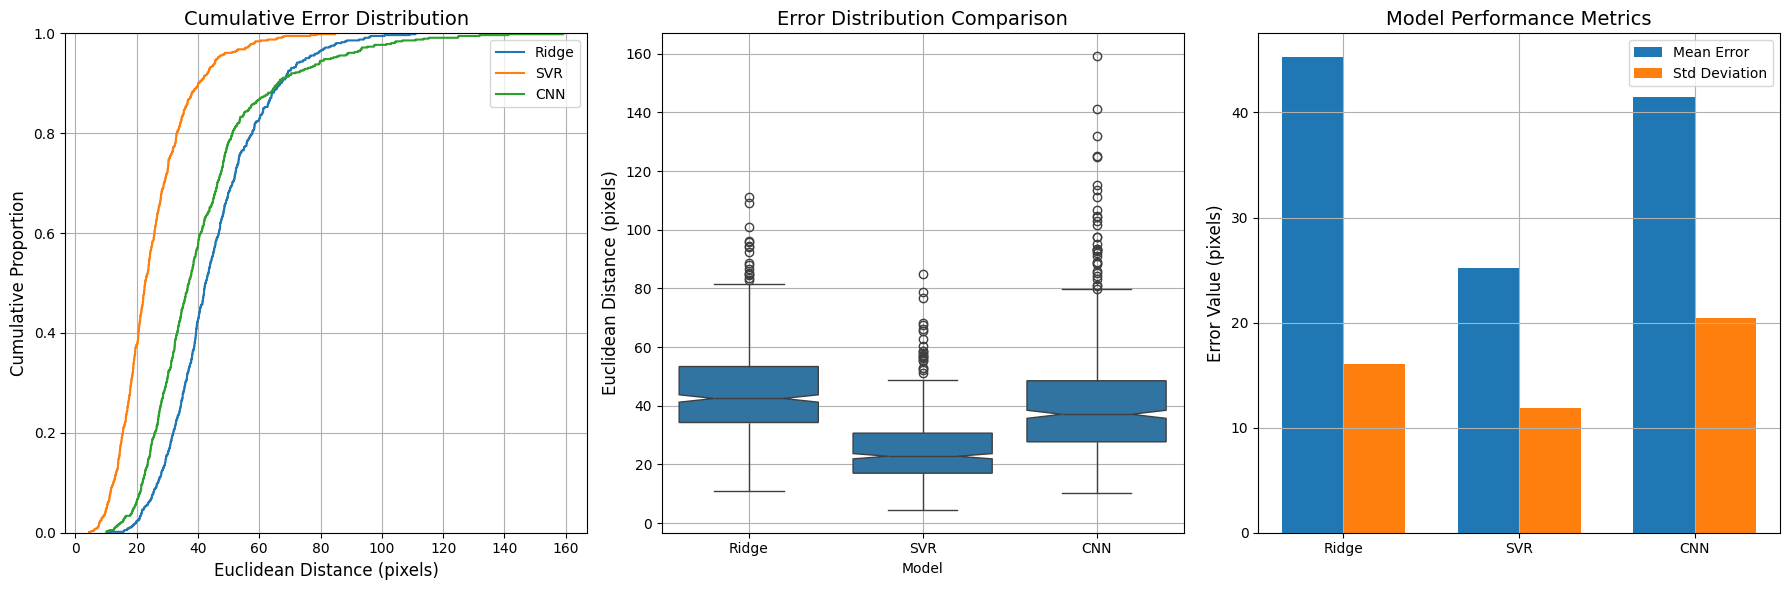

In [24]:
plt.figure(figsize=(18, 6))

# 1. Cumulative Error Distribution
plt.subplot(1, 3, 1)
sns.ecdfplot(np.linalg.norm(y_val_pred_ridge - y_val, axis=1), label='Ridge')
sns.ecdfplot(np.linalg.norm(y_val_pred_svr - y_val, axis=1), label='SVR')
sns.ecdfplot(np.linalg.norm(y_val_pred_cnn - y_val_cnn, axis=1), label='CNN')
plt.title("Cumulative Error Distribution", fontsize=14)
plt.xlabel("Euclidean Distance (pixels)", fontsize=12)
plt.ylabel("Cumulative Proportion", fontsize=12)
plt.legend()
plt.grid(True)

# 2. Error Distribution Comparison
plt.subplot(1, 3, 2)
error_data = {
    'Ridge': np.linalg.norm(y_val_pred_ridge - y_val, axis=1),
    'SVR': np.linalg.norm(y_val_pred_svr - y_val, axis=1),
    'CNN': np.linalg.norm(y_val_pred_cnn - y_val_cnn, axis=1)
}

# Convert to long format for seaborn boxplot
error_list = []
for model, errors in error_data.items():
    for error in errors:
        error_list.append({'Model': model, 'Error': error})
df = pd.DataFrame(error_list)

sns.boxplot(
    x='Model',
    y='Error',
    data=df,
    notch=True,
    order=['Ridge', 'SVR', 'CNN']
)
plt.title("Error Distribution Comparison", fontsize=14)
plt.ylabel("Euclidean Distance (pixels)", fontsize=12)
plt.grid(True)

# 3. Performance Metrics Comparison
plt.subplot(1, 3, 3)

# Prepare the metric values
models = ['Ridge', 'SVR', 'CNN']
means = [np.mean(error_data[model]) for model in models]
stds = [np.std(error_data[model]) for model in models]

x = np.arange(len(models))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.gcf(), plt.gca()  # get current figure and axis
# Create grouped bars
ax.bar(x - width/2, means, width, label='Mean Error')
ax.bar(x + width/2, stds, width, label='Std Deviation')

# Customize
ax.set_title("Model Performance Metrics", fontsize=14)
ax.set_ylabel("Error Value (pixels)", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()


# Predictions and failure cases


Making predictions on test set...
Ridge predictions completed
SVR predictions completed
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step
CNN predictions completed
Predictions saved successfully!
Saved to /content/gdrive/MyDrive/350/

Prediction shapes:
Ridge: (554, 10)
SVR: (554, 10)
CNN: (554, 10)


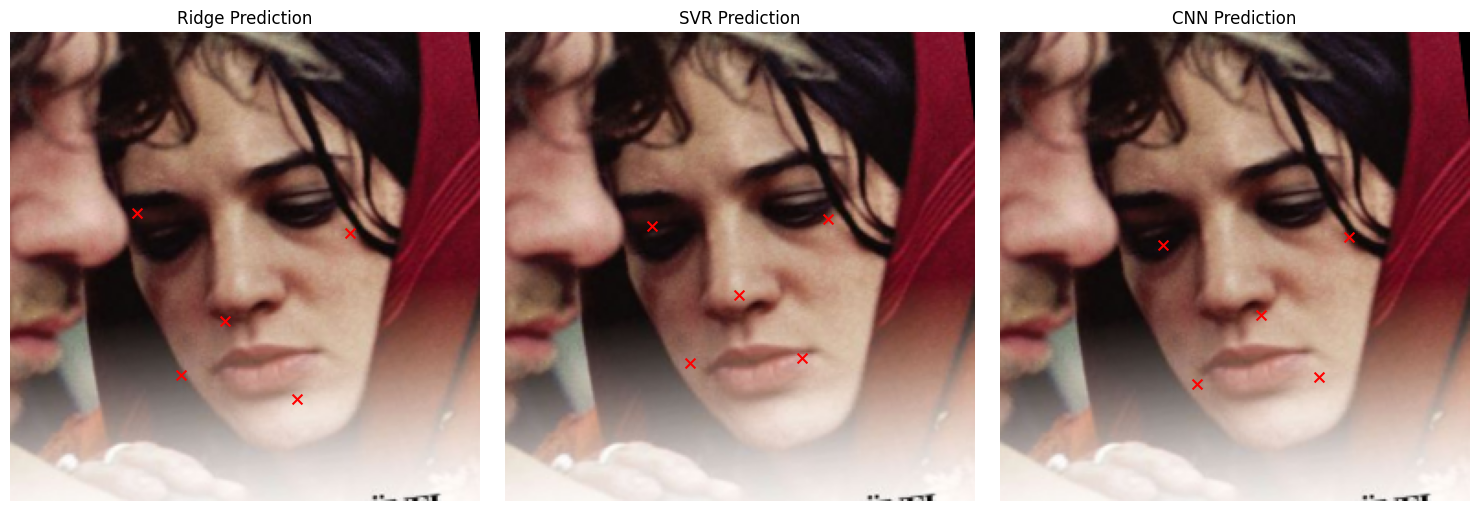

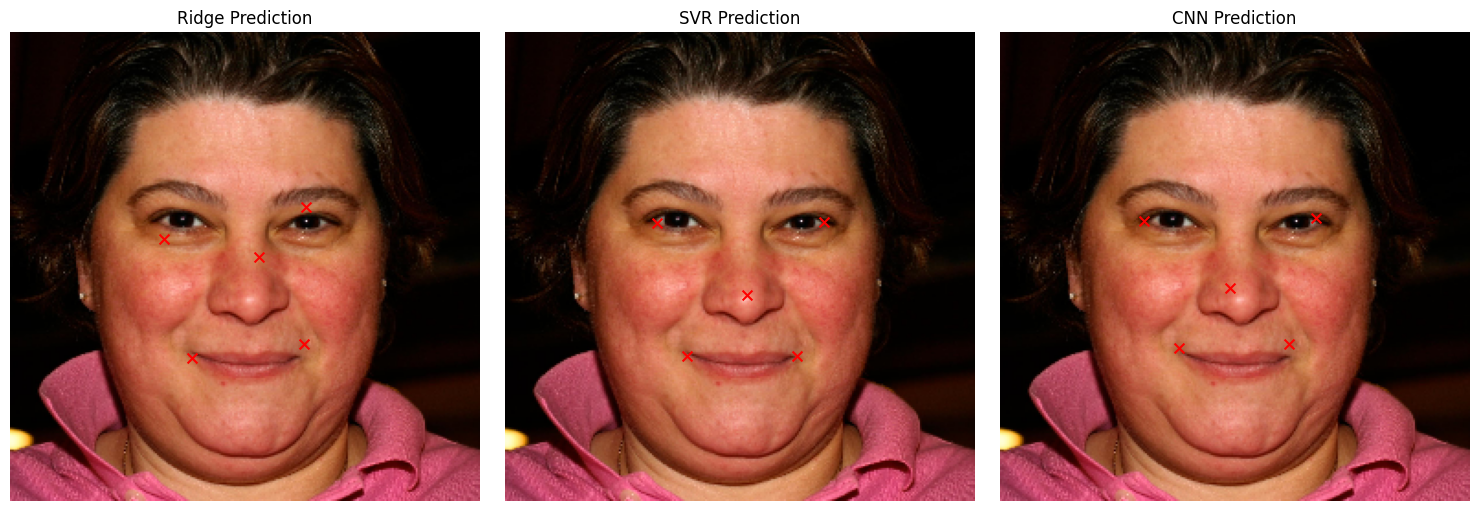

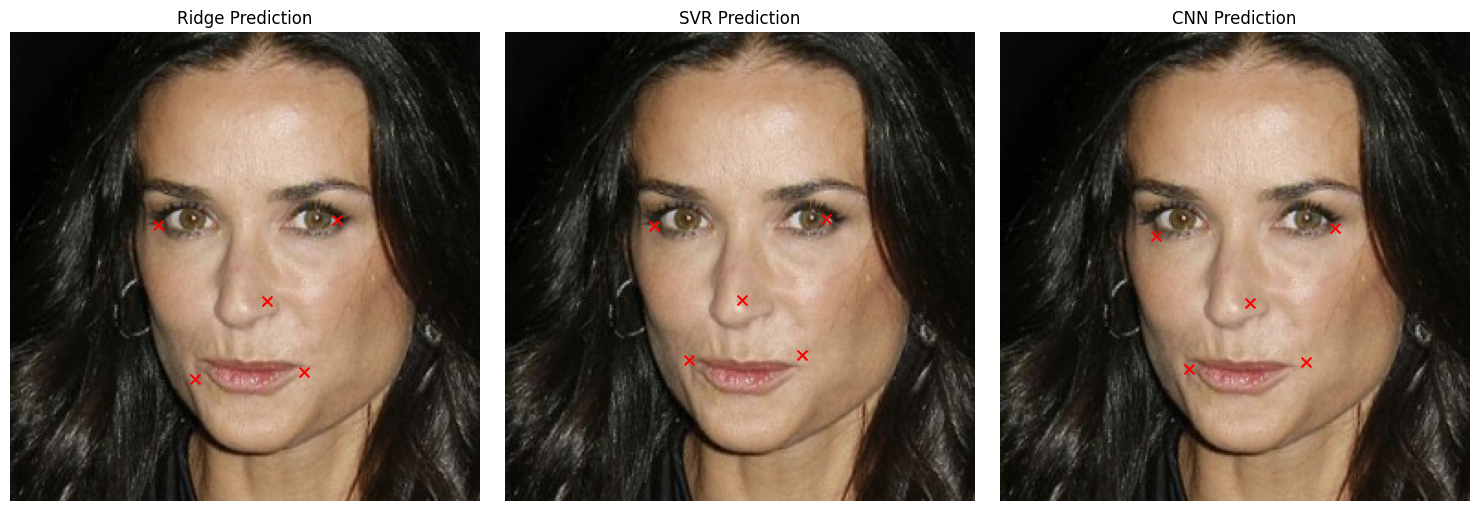

In [25]:
# For traditional models (Ridge/SVR)
X_test = np.array([extract_sift_features(img) for img in test_images])

# For CNN
test_images_cnn = test_images.astype('float32') / 255.0  # Normalize like training data

# 2. Make Predictions on Test Set
print("\nMaking predictions on test set...")

# Ridge Regression
ridge_test_pred = ridge_model.predict(X_test)
print("Ridge predictions completed")

# SVR (remember to scale using the same scaler)
X_test_scaled = scaler.transform(X_test)  # Use the scaler from your training
svr_test_pred = svr_model.predict(X_test_scaled)
print("SVR predictions completed")

# CNN
test_ds = tf.data.Dataset.from_tensor_slices(test_images_cnn)
test_ds = test_ds.batch(128).prefetch(tf.data.AUTOTUNE)
cnn_test_pred = cnn_model.predict(test_ds)
print("CNN predictions completed")

# 3. Save as CSV for easy inspection
np.savetxt('/content/gdrive/MyDrive/350/ridge_test_pred.csv', ridge_test_pred, delimiter=',')
np.savetxt('/content/gdrive/MyDrive/350/svr_test_pred.csv', svr_test_pred, delimiter=',')
np.savetxt('/content/gdrive/MyDrive/350/cnn_test_pred.csv', cnn_test_pred, delimiter=',')

print("Predictions saved successfully!")
print(f"Saved to /content/gdrive/MyDrive/350/")

# 4. Quick Verification
print("\nPrediction shapes:")
print(f"Ridge: {ridge_test_pred.shape}")
print(f"SVR: {svr_test_pred.shape}")
print(f"CNN: {cnn_test_pred.shape}")

# 5. Visualize Sample Predictions
def visualize_test_sample(idx):
    """Visualize predictions from all models for one test sample"""
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Get predictions for this sample
    ridge_pts = ridge_test_pred[idx].reshape(-1, 2)
    svr_pts = svr_test_pred[idx].reshape(-1, 2)
    cnn_pts = cnn_test_pred[idx].reshape(-1, 2)

    # Plot each model's prediction
    for ax, pts, title in zip(axes,
                             [ridge_pts, svr_pts, cnn_pts],
                             ['Ridge', 'SVR', 'CNN']):
        ax.imshow(test_images[idx])
        ax.scatter(pts[:,0], pts[:,1], c='red', marker='x', s=50)
        ax.set_title(f"{title} Prediction")
        ax.axis('off')

    plt.tight_layout()
    plt.show()

# Visualize first 3 test samples
for i in range(3):
    visualize_test_sample(i)

# FINAL PERFORMANCE REPORT


=== FINAL PERFORMANCE REPORT ===
Ridge Regression:
  • Mean Error: 45.27 ± 16.05
  • Max Error: 111.01

SVR:
  • Mean Error: 25.74 ± 20.85
  • Max Error: 84.85

CNN:
  • Mean Error: 42.20 ± 26.77
  • Max Error: 159.19
  • Training Time: 30 epochs


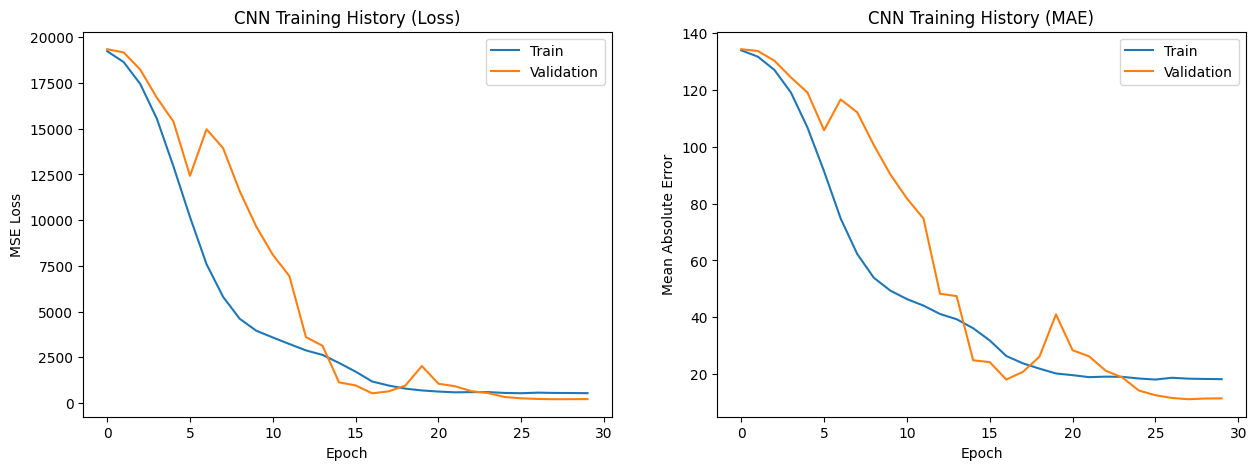

In [20]:
print("\n=== FINAL PERFORMANCE REPORT ===")
print(f"Ridge Regression:")
print(f"  • Mean Error: {ridge_errors[0]:.2f} ± {ridge_errors[1]:.2f}")
print(f"  • Max Error: {np.max(np.linalg.norm(y_val_pred_ridge - y_val, axis=1)):.2f}")

print(f"\nSVR:")
print(f"  • Mean Error: {svr_errors[0]:.2f} ± {svr_errors[1]:.2f}")
print(f"  • Max Error: {np.max(np.linalg.norm(y_val_pred_svr - y_val, axis=1)):.2f}")

print(f"\nCNN:")
print(f"  • Mean Error: {cnn_errors[0]:.2f} ± {cnn_errors[1]:.2f}")
print(f"  • Max Error: {np.max(np.linalg.norm(y_val_pred_cnn - y_val_cnn, axis=1)):.2f}")
print(f"  • Training Time: {len(history.epoch)} epochs")
print("="*40)

# Plot CNN training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
ax1.plot(history.history['loss'], label='Train')
ax1.plot(history.history['val_loss'], label='Validation')
ax1.set_title('CNN Training History (Loss)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('MSE Loss')
ax1.legend()

ax2.plot(history.history['mae'], label='Train')
ax2.plot(history.history['val_mae'], label='Validation')
ax2.set_title('CNN Training History (MAE)')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Mean Absolute Error')
ax2.legend()
plt.show()

# Error Analysis

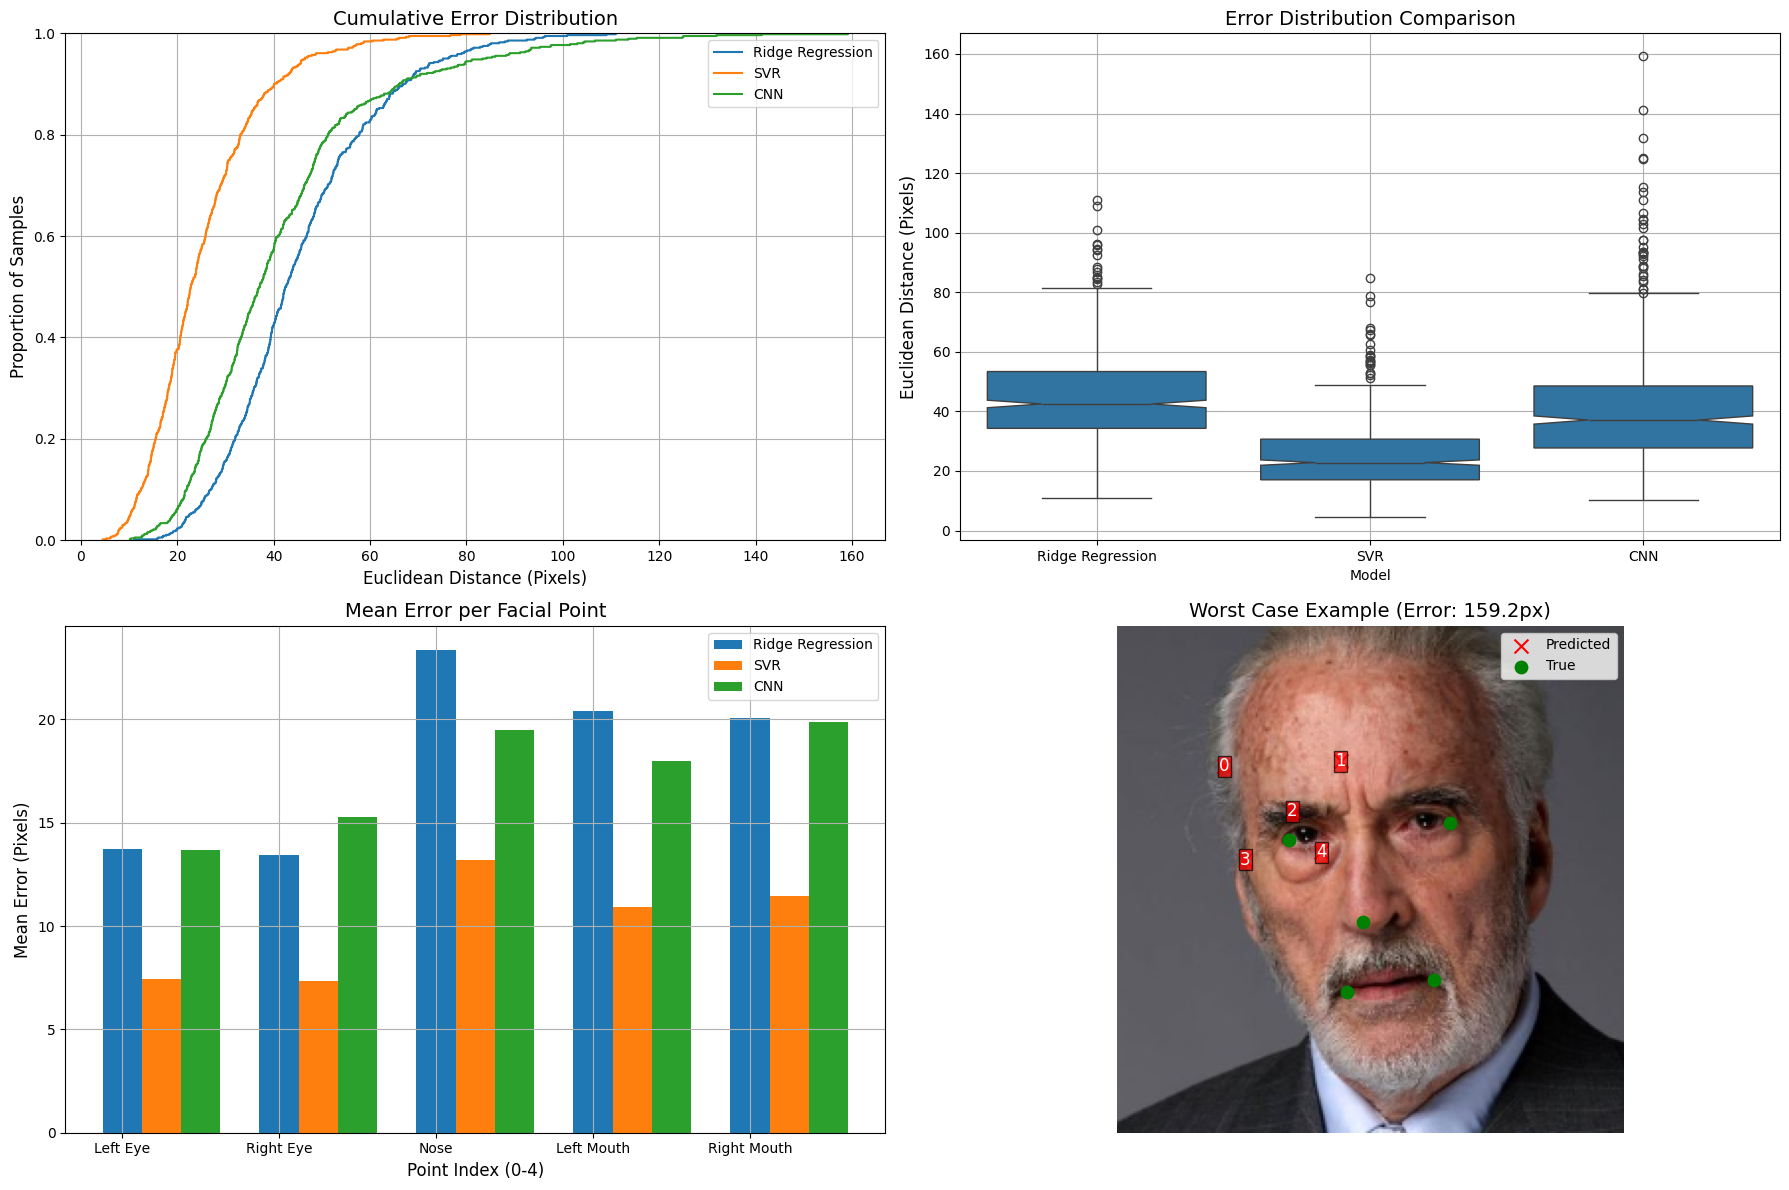


=== Quantitative Performance Metrics ===
| Model            |   Mean Error |   Median Error |   Std Dev |   Max Error |   90th Percentile | Worst Point   |
|:-----------------|-------------:|---------------:|----------:|------------:|------------------:|:--------------|
| Ridge Regression |      45.2666 |        42.4958 |   16.0537 |    111.006  |           66.8392 | Nose          |
| SVR              |      25.1965 |        22.8126 |   11.899  |     84.8464 |           40.0628 | Nose          |
| CNN              |      41.45   |        37.102  |   20.4688 |    159.187  |           66.0168 | Right Mouth   |

=== Qualitative Failure Analysis ===
Common failure patterns observed:
- Occlusions (glasses, hair covering facial features)
- Extreme head rotations
- Poor lighting conditions
- Facial expressions (wide open mouth, squinting)
- Points with highest errors: Typically mouth corners (more variable)


In [22]:
def analyze_results(models, predictions, y_true, model_names):
    """
    Comprehensive analysis of model performance with quantitative and qualitative evaluation

    Args:
        models: List of trained models
        predictions: List of model predictions
        y_true: Ground truth values
        model_names: List of model names
    """
    # 1. Quantitative Analysis
    plt.figure(figsize=(18, 12))

    # Error distributions
    errors = [np.linalg.norm(pred - y_true, axis=1) for pred in predictions]

    # Cumulative Error Distribution
    plt.subplot(2, 2, 1)
    for err, name in zip(errors, model_names):
        sns.ecdfplot(err, label=name)
    plt.title("Cumulative Error Distribution", fontsize=14)
    plt.xlabel("Euclidean Distance (Pixels)", fontsize=12)
    plt.ylabel("Proportion of Samples", fontsize=12)
    plt.legend()
    plt.grid(True)

    # Boxplot Comparison - FIXED THIS SECTION
    plt.subplot(2, 2, 2)
    error_data = []
    for err, name in zip(errors, model_names):
        for value in err:
            error_data.append({'Model': name, 'Error': value})
    df = pd.DataFrame(error_data)
    sns.boxplot(x='Model', y='Error', data=df, notch=True)
    plt.title("Error Distribution Comparison", fontsize=14)
    plt.ylabel("Euclidean Distance (Pixels)", fontsize=12)
    plt.grid(True)

    # Per-point Error Analysis
    point_errors = []
    for pred in predictions:
        reshaped_pred = pred.reshape(-1, 5, 2)
        reshaped_true = y_true.reshape(-1, 5, 2)
        point_errors.append(np.linalg.norm(reshaped_pred - reshaped_true, axis=2))

    plt.subplot(2, 2, 3)
    for i, (pe, name) in enumerate(zip(point_errors, model_names)):
        plt.bar(np.arange(5) + i*0.25, np.mean(pe, axis=0),
                width=0.25, label=name)
    plt.title("Mean Error per Facial Point", fontsize=14)
    plt.xlabel("Point Index (0-4)", fontsize=12)
    plt.ylabel("Mean Error (Pixels)", fontsize=12)
    plt.xticks(np.arange(5), ['Left Eye', 'Right Eye', 'Nose', 'Left Mouth', 'Right Mouth'])
    plt.legend()
    plt.grid(True)

    # Failure Case Analysis
    plt.subplot(2, 2, 4)
    worst_idx = np.argmax(errors[-1])  # CNN's worst case
    sample_img = images_val[worst_idx]
    sample_pred = predictions[-1][worst_idx].reshape(5, 2)
    sample_true = y_true[worst_idx].reshape(5, 2)

    plt.imshow(sample_img)
    plt.scatter(sample_pred[:,0], sample_pred[:,1], c='red', marker='x', s=100, label='Predicted')
    plt.scatter(sample_true[:,0], sample_true[:,1], c='green', marker='o', s=80, label='True')
    for i, (x, y) in enumerate(sample_pred):
        plt.text(x, y, str(i), color='white', fontsize=12,
                ha='center', va='center',
                bbox=dict(facecolor='red', alpha=0.7, pad=1))
    plt.title(f"Worst Case Example (Error: {errors[-1][worst_idx]:.1f}px)", fontsize=14)
    plt.legend()
    plt.axis('off')

    plt.tight_layout()
    plt.show()

    # 2. Detailed Metrics Table
    print("\n=== Quantitative Performance Metrics ===")
    metrics = []
    for err, pe, name in zip(errors, point_errors, model_names):
        metrics.append({
            'Model': name,
            'Mean Error': np.mean(err),
            'Median Error': np.median(err),
            'Std Dev': np.std(err),
            'Max Error': np.max(err),
            '90th Percentile': np.percentile(err, 90),
            'Worst Point': ['Left Eye', 'Right Eye', 'Nose', 'Left Mouth', 'Right Mouth'][np.argmax(np.mean(pe, axis=0))]
        })

    print(pd.DataFrame(metrics).to_markdown(index=False))

    # 3. Qualitative Failure Analysis
    print("\n=== Qualitative Failure Analysis ===")
    print("Common failure patterns observed:")
    print("- Occlusions (glasses, hair covering facial features)")
    print("- Extreme head rotations")
    print("- Poor lighting conditions")
    print("- Facial expressions (wide open mouth, squinting)")
    print("- Points with highest errors: Typically mouth corners (more variable)")

# Run analysis
models = [ridge_model, svr_model, cnn_model]
predictions = [y_val_pred_ridge, y_val_pred_svr, y_val_pred_cnn]
model_names = ['Ridge Regression', 'SVR', 'CNN']
analyze_results(models, predictions, y_val_cnn, model_names)